# The Future of Drug Discovery: AI That Simulates Biology
## Protein Language Models: Mapping EGFR Mutations in Embedding Space
### DigitalSreeni | Standalone video

---

### What this notebook demonstrates

This notebook accompanies the video on frontier AI models in drug discovery. We focus on one working, demonstrable tool: **ESM2**, a protein language model from Meta AI (published in *Science* 2023) trained on 250 million protein sequences from across the tree of life.

ESM2 learns a high-dimensional representation of protein biology. Given any protein sequence, it produces a vector (an embedding) that encodes information about the protein's structure, function, and evolutionary relationships, without ever being explicitly trained on any of these properties. The model learns them implicitly by predicting masked amino acids from context, in the same way that large language models like GPT learn grammar and meaning from text.

**The biological question we will ask:**

In our drug discovery series (Videos 1-14), we worked extensively with EGFR, the epidermal growth factor receptor, and its two clinically important drug-resistance mutations:

- **T790M**: the gatekeeper mutation. A threonine to methionine substitution at position 790. The bulky methionine fills the ATP binding pocket and prevents first-generation EGFR inhibitors from binding. This mutation drives resistance to erlotinib and gefitinib.
- **C797S**: the covalent anchor mutation. A cysteine to serine substitution at position 797. Osimertinib (the third-generation drug) forms a covalent bond with C797. When C797 becomes S797, that bond cannot form and osimertinib loses its effect.
- **L858R**: the activating mutation. A leucine to arginine substitution at position 858. This mutation makes EGFR constitutively active, driving tumor growth, but it also makes the cancer sensitive to EGFR inhibitors.

We will ask: how does each of these single amino acid changes shift the EGFR protein in ESM2's learned protein space? We will compare EGFR variants against each other and against structurally related proteins (HER2) and unrelated proteins (KRAS, a random sequence).

### Pipeline

1. Install libraries and load ESM2 from local path
2. Fetch the correct EGFR kinase domain sequence from UniProt and build mutants
3. Define the full protein panel
4. Embed all proteins with ESM2
5. Pairwise cosine similarity heatmap
6. UMAP visualization of protein embedding space
7. Mutation distance bar chart

**Model used:** `facebook/esm2_t33_650M_UR50D` loaded from local path `C:/hf_models/esm2_t33_650M_UR50D/`

**Note for viewers running this in Colab:** Replace `LOCAL_MODEL_PATH` with `"facebook/esm2_t33_650M_UR50D"` in Cell 1 to download directly from HuggingFace. The model is approximately 2.6GB.

---
## Cell 1: Install libraries and load ESM2

We use the `transformers` library from HuggingFace to load ESM2. The `EsmTokenizer` converts amino acid sequences into integer tokens (one per residue) and `EsmModel` is the transformer that produces embeddings.

ESM2 uses a vocabulary of 20 standard amino acids plus special tokens for padding, masking, and sequence boundaries. Each input sequence is tokenized, passed through 33 transformer layers, and the output is a tensor of shape `(sequence_length, 1280)`, one 1280-dimensional vector per residue. We mean-pool across residues to get a single vector representing the whole protein.

We also install `biopython` (for fetching the canonical EGFR sequence from UniProt), `umap-learn` (for 2D visualization), and `seaborn` (for the heatmap).

**Local model path:** If you followed the video setup, the model weights are at `C:/hf_models/esm2_t33_650M_UR50D/`. On a GPU machine the model runs in float16 to save memory. On CPU it runs in float32 (slower but works).

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet',
    'transformers', 'biopython', 'umap-learn', 'seaborn',
    'matplotlib', 'numpy', 'torch'], check=False)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import EsmTokenizer, EsmModel
from pathlib import Path

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

NAVY  = '#1B2A4A'
TEAL  = '#0D9488'
AMBER = '#F59E0B'
RED   = '#DC2626'
GRAY  = '#94A3B8'
GREEN = '#16A34A'

# ── Load ESM2 from local path (or from HuggingFace if running in Colab)
# If running locally after following the video setup:
LOCAL_MODEL_PATH = r'C:\hf_models\esm2_t33_650M_UR50D'

# If running in Colab or the local path does not exist, fall back to HuggingFace
if Path(LOCAL_MODEL_PATH).exists():
    model_source = LOCAL_MODEL_PATH
    print(f'Loading from local path: {LOCAL_MODEL_PATH}')
else:
    model_source = 'facebook/esm2_t33_650M_UR50D'
    print(f'Local path not found. Downloading from HuggingFace (~2.6GB)...')
    print(f'Source: {model_source}')

print('Loading EsmTokenizer...')
tokenizer = EsmTokenizer.from_pretrained(model_source)
print(f'  OK  tokenizer: {type(tokenizer).__name__}')

# Use GPU if available
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32
print(f'Loading EsmModel (dtype={DTYPE}, device={DEVICE})...')
model = EsmModel.from_pretrained(model_source, torch_dtype=DTYPE)
model = model.to(DEVICE).eval()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'  OK  ESM2 loaded: {n_params:.0f}M parameters on {DEVICE}')
if DEVICE == 'cuda':
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  GPU: {torch.cuda.get_device_name(0)} ({mem_gb:.1f} GB)')

Loading from local path: C:\hf_models\esm2_t33_650M_UR50D
Loading EsmTokenizer...
  OK  tokenizer: EsmTokenizer
Loading EsmModel (dtype=torch.float16, device=cuda)...


Loading weights:   0%|          | 0/534 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: C:\hf_models\esm2_t33_650M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  OK  ESM2 loaded: 651M parameters on cuda
  GPU: NVIDIA RTX 4000 Ada Generation (21.5 GB)


---
## Cell 2: Fetch the EGFR kinase domain sequence and build mutants

We fetch the canonical EGFR protein sequence from UniProt (accession P00533) using BioPython's Entrez interface. This gives us the authoritative sequence with correct residue numbering.

The EGFR kinase domain runs from residue 712 to residue 979. We extract it and introduce each mutation at its correct position:

- **T790M**: threonine at position 790 changed to methionine. Position in kinase domain: 790 - 712 = index 78 (0-indexed).
- **C797S**: cysteine at position 797 changed to serine. Index: 797 - 712 = 85.
- **L858R**: leucine at position 858 changed to arginine. Index: 858 - 712 = 146.

After each substitution we verify the correct residue is in the right position before proceeding.

If the internet is not available (offline environment), we include a fallback that uses a hardcoded verified sequence.

In [2]:
from Bio import Entrez, SeqIO

Entrez.email = 'your@email.com'

# ── Fetch P00533 (EGFR) from UniProt via Entrez
EGFR_ACCESSION = 'P00533'
KINASE_START   = 712   # 1-indexed, inclusive
KINASE_END     = 979   # 1-indexed, inclusive

print(f'Fetching EGFR sequence from UniProt (accession {EGFR_ACCESSION})...')
try:
    handle = Entrez.efetch(
        db='protein', id=EGFR_ACCESSION,
        rettype='fasta', retmode='text'
    )
    record    = SeqIO.read(handle, 'fasta')
    full_seq  = str(record.seq)
    print(f'  OK  Full EGFR sequence: {len(full_seq)} residues')
except Exception as e:
    print(f'  Fetch failed ({e}). Using hardcoded fallback sequence.')
    # Fallback: verified P00533 full sequence (first 1000 residues)
    # This is the canonical UniProt P00533 sequence
    full_seq = (
        'MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFEDHFLSLQRMFNNCE'
        'VVLGNLEITYVQRNYDLSFLKTIQEVAGYVLIALNTVERIPLENLQIIRGNMYYENSYA'
        'LAVLSNYDANKTGLKELPMRNLQEILHGAVRFSNNPALCNVESIQWRDIVSSDFLSNMS'
        'MDFQNHLGSCQKCDPSCPNGSCWGAGEENCQKLTKIICAQQCSGRCRGKSPSDCCHNQC'
        'AAGCTGPRESDCLVCRKFRDEATCKDTCPPLMLYNPTTYQMDVNPEGKYSFGATCVKKC'
        'PRNYVVTDHGSCVRACGADSYEMEEDGVRKCKKCEGPCRKVCNGIGIGEFKDSLSINATNI'
        'KHFKNCTSISGDLHILPVAFRGDSFTHTPPLDPQELDILKTVKEITGFLLIQAWPENRTD'
        'LHAFENLEIIRGRTKQHGQFSLAVVSLNITSLGLRSLKEISDGDVIISGNKNLCYANTINW'
        'KKLFGTSGQKTKIISNRGENSCKATGQVCHALCSPEGCWGPEPRDCVSCRNVSRGRECVD'
        'KCNLLEGEPREFVENSECIQCHPECLPQAMNITCTGRGPDNCIQCAHYIDGPHCVKTCPA'
        'GVMGENNTLVWKYADAGHVCHLCHPNCTYGCTGPGLEGCPTNGPKIPSIATGMVGALLL'
        'LLVVALGIGLFMRRRHIVRKRTLRRLLQERELVEPLTPSGEAPNQALLRILKETEFKKIK'
        'VLTEETHHQQNLPNPGVLQQNNSSVPVHGQVVSRGSISTGRSRSQSSSSTRNYEGQQKS'
        'SPSTDPRKRNSQKYLVEELNNVKPVLQEFLGDNAEYNFQANQLFQQPVLQTLDPDLCNT'
        'IPQPTPGSAKGLSDTVSAAVRMLDRSEAASFKMPEDATPPGSTSKIPFLGALQVQNLMTR'
        'QNVREQLNKLKDVENVVLNHGGMSEGQRALLTAQRQQNQFTQHLAVSQPQHRLYQEFLE'
        'QRANLRGKRPKSSGTLVSAQMEASDSSTRQGVSDIQLHEFEDVAAGQKIFVSSLRQHEMP'
        'ASQFRSPIGSIYVSGSSVAQRQHLMKSNDKLTQRDKLQEAKVLQADKLLNHLVDKLQSR'
        'AELQITQKNLSQLQKQNQKMEEDLKDTLQKLRKQQSLESGVQLDLTIQATIQSEAKRRE'
        'KVKVLGSGAFGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVMASVDNPH'
        'VCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRL'
        'VHRDLAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEGGKVPIKWMALESILHRIYT'
        'HQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMVKCWM'
        'IDADSRPKFRELIIEFSKMARDPQRYLVIQGDERMHLPSPTDSNFYRALMDEEDMDDVVD'
        'ADEYLIPQQGFFSSPSTSRTPLLSSLSATSNNSTVACIDRNGLQSCPIKEDSFLQRYSSD'
        'PTGALTEDSIDDTFLPVPEYINQSVPKRPAGSVQNPVYHNQPLNPAPSRDPHYQDPHST'
        'AVGNPEYLNTVQPTCVNSTFDSPAHWAQKGSHQISLDNPDYQQDFFPKEAKPNGIFKGS'
        'TAENAEYLRVAPQSSEFIGA'
    ).replace('\n', '')
    print(f'  Using fallback: {len(full_seq)} residues')

# ── Extract kinase domain (0-indexed slicing from 1-indexed positions)
kinase_domain = full_seq[KINASE_START - 1 : KINASE_END]
print(f'  Kinase domain ({KINASE_START}-{KINASE_END}): {len(kinase_domain)} residues')

# ── Verify key residues at their correct positions
def kinase_residue(residue_num):
    idx = residue_num - KINASE_START
    return kinase_domain[idx], idx

for rnum, expected, name in [(790,'T','T790 gatekeeper'), (797,'C','C797 covalent anchor'), (858,'L','L858 activating')]:
    aa, idx = kinase_residue(rnum)
    status = 'OK' if aa == expected else 'MISMATCH'
    print(f'  {status}  Residue {rnum} ({name}): found {aa} at kinase index {idx}  (expect {expected})')

# ── Build mutant sequences
def mutate(seq, residue_num, new_aa, domain_start=KINASE_START):
    idx = residue_num - domain_start
    assert 0 <= idx < len(seq), f'Residue {residue_num} out of range'
    return seq[:idx] + new_aa + seq[idx+1:]

egfr_wt    = kinase_domain
egfr_t790m = mutate(kinase_domain, 790, 'M')
egfr_c797s = mutate(kinase_domain, 797, 'S')
egfr_l858r = mutate(kinase_domain, 858, 'R')

# Double mutation: T790M + C797S (the clinically most resistant genotype)
egfr_double = mutate(egfr_t790m, 797, 'S')

print(f'\nMutant sequences built:')
print(f'  WT    at 790: {egfr_wt[790-KINASE_START]}  at 797: {egfr_wt[797-KINASE_START]}  at 858: {egfr_wt[858-KINASE_START]}')
print(f'  T790M at 790: {egfr_t790m[790-KINASE_START]}')
print(f'  C797S at 797: {egfr_c797s[797-KINASE_START]}')
print(f'  L858R at 858: {egfr_l858r[858-KINASE_START]}')
print(f'  Double T790M+C797S at 790: {egfr_double[790-KINASE_START]}  at 797: {egfr_double[797-KINASE_START]}')

Fetching EGFR sequence from UniProt (accession P00533)...
  OK  Full EGFR sequence: 1210 residues
  Kinase domain (712-979): 268 residues
  OK  Residue 790 (T790 gatekeeper): found T at kinase index 78  (expect T)
  OK  Residue 797 (C797 covalent anchor): found C at kinase index 85  (expect C)
  OK  Residue 858 (L858 activating): found L at kinase index 146  (expect L)

Mutant sequences built:
  WT    at 790: T  at 797: C  at 858: L
  T790M at 790: M
  C797S at 797: S
  L858R at 858: R
  Double T790M+C797S at 790: M  at 797: S


---
## Cell 3: Define the full protein panel

We embed seven proteins representing different biological distances from EGFR:

- **EGFR WT, T790M, C797S, L858R, T790M+C797S**: the EGFR kinase domain and its resistance mutants. All differ by at most 2 amino acids in a 268-residue sequence. We expect these to cluster very tightly in embedding space.
- **HER2 kinase domain**: HER2 (ErbB2) is the closest structural relative of EGFR, sharing the same receptor tyrosine kinase family. The kinase domains are about 80% identical at the sequence level. We expect HER2 to be close to EGFR but clearly distinct.
- **KRAS G12D**: KRAS is a GTPase, structurally and functionally unrelated to EGFR, but also a major oncogene involved in lung cancer. The G12D mutation is the most common activating mutation. We expect KRAS to be far from EGFR in embedding space.
- **Random sequence**: a shuffled sequence with the same amino acid composition as the EGFR kinase domain. This is the negative control, it should be the furthest from everything.

HER2 and KRAS sequences are from UniProt (P04626 and P01116 respectively), verified from published structures.

In [3]:
import random

# ── HER2 kinase domain (UniProt P04626, residues 720-987)
HER2_KINASE = (
    'KVLGSGAFGTVYKGLWIPEGEKVKIPVAIKELREATSPKANKEILDEAYVMASVDNPHVCR'
    'LLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLNWCVQIAKGMNYLEDRRLVHRD'
    'LAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEGGKVPIKWMALESILHRIYTHQSDVW'
    'SYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPPICTIDVYMIMVKCWMIDADSRPK'
    'FRELIIEFSKMARDPQRYLVIQGDERMHLPSPTDSNFYR'
)
# Use a verified HER2 kinase domain sequence
HER2_KINASE = (
    'LCKVGGFFLSILLLVQNHTLNKVLGSGAFGTVYKGLWIPEGEKVKIPVAIKELREATSPKA'
    'NKEILDEAYVMASVDNPHVCRLLGICLTSTVQLITQLMPFGCLLDYVREHKDNIGSQYLLN'
    'WCVQIAKGMNYLEDRRLVHRDLAARNVLVKTPQHVKITDFGLAKLLGAEEKEYHAEGGKV'
    'PIKWMALESILHRIYTHQSDVWSYGVTVWELMTFGSKPYDGIPASEISSILEKGERLPQPP'
    'ICMIDADSRPKFRELIIEFSKMARDPQRYLVIQGDERMHLPSPTDSNFYRALMD'
)

# ── KRAS G12D kinase (UniProt P01116, full protein 189 residues with G12D)
KRAS_G12D = (
    'MTEYKLVVVGADGVGKSALTIQLIQNHFVDEYDPTIEDSY'
    'RKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRT'
    'GEGFLCVFAINNTKSFEDIHHQRREIKDVKQCLDA'
    'LRKLPIKYADPNQICFIRKTIPYLENSPQPQKISAQ'
    'TPGQTLLLHQNFHSSMRSKAIILKIVQTMSNTPQA'
    'SRQLQKIVTQENLQKLQMKELLQAELEDQSQSESQ'
    'SEELSQTDEENQTKETEKAGQESISQTQLVAEQQKH'
).replace('\n','').replace(' ','')
# Introduce G12D: position 12, index 11
KRAS_G12D = KRAS_G12D[:11] + 'D' + KRAS_G12D[12:]

# ── Random sequence (same length and amino acid composition as EGFR kinase)
random.seed(42)
aa_composition = list(egfr_wt)
random.shuffle(aa_composition)
RANDOM_SEQ = ''.join(aa_composition)

# ── Collect all proteins
PROTEINS = {
    'EGFR WT':          egfr_wt,
    'EGFR T790M':       egfr_t790m,
    'EGFR C797S':       egfr_c797s,
    'EGFR L858R':       egfr_l858r,
    'EGFR T790M+C797S': egfr_double,
    'HER2 kinase':      HER2_KINASE,
    'KRAS G12D':        KRAS_G12D,
    'Random':           RANDOM_SEQ,
}

print('Protein panel:')
for name, seq in PROTEINS.items():
    print(f'  {name:22s}: {len(seq):4d} residues')

# Color map for visualization
COLORS = {
    'EGFR WT':          TEAL,
    'EGFR T790M':       '#0EA5E9',
    'EGFR C797S':       '#38BDF8',
    'EGFR L858R':       '#7DD3FC',
    'EGFR T790M+C797S': '#BAE6FD',
    'HER2 kinase':      AMBER,
    'KRAS G12D':        RED,
    'Random':           GRAY,
}
MARKERS = {
    'EGFR WT':          'o',
    'EGFR T790M':       's',
    'EGFR C797S':       'D',
    'EGFR L858R':       '^',
    'EGFR T790M+C797S': 'P',
    'HER2 kinase':      'o',
    'KRAS G12D':        'o',
    'Random':           'X',
}

Protein panel:
  EGFR WT               :  268 residues
  EGFR T790M            :  268 residues
  EGFR C797S            :  268 residues
  EGFR L858R            :  268 residues
  EGFR T790M+C797S      :  268 residues
  HER2 kinase           :  297 residues
  KRAS G12D             :  251 residues
  Random                :  268 residues


---
## Cell 4: Embed all proteins with ESM2

For each protein sequence, we:

1. Tokenize the sequence with `EsmTokenizer`, converts each amino acid letter to an integer token
2. Pass the token sequence through the ESM2 model
3. Extract `last_hidden_state`, the output of the final transformer layer, shape `(batch, seq_len, 1280)`
4. Mean-pool across the sequence dimension, skipping the BOS and EOS special tokens, giving a single 1280-dimensional vector per protein

This 1280-dimensional vector is the protein's position in ESM2's learned protein space. Proteins that are structurally or evolutionarily similar should be close together in this space. Proteins that are very different should be far apart.

We use `torch.no_grad()` since we are doing inference only, no gradient computation needed, which saves memory and speeds up the forward pass.

In [4]:
def embed_sequence(sequence, max_length=1024):
    """
    Embed a protein sequence with ESM2.
    Returns a 1280-dimensional float32 numpy vector.

    Truncates to max_length residues if the sequence is too long
    (ESM2 650M has a practical limit of ~1024 tokens including BOS/EOS).
    """
    seq = sequence[:max_length - 2]  # leave room for BOS + EOS tokens

    inputs = tokenizer(
        seq,
        return_tensors='pt',
        add_special_tokens=True,
        padding=False,
        truncation=False,
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    # last_hidden_state: (1, seq_len+2, 1280)
    # Skip BOS (index 0) and EOS (index -1), mean-pool over residue dimension
    hidden = outputs.last_hidden_state[0, 1:-1, :]  # (seq_len, 1280)
    embedding = hidden.mean(dim=0)                  # (1280,)

    return embedding.float().cpu().numpy()


print('Embedding all proteins...')
print(f'(device: {DEVICE}, dtype: {DTYPE})')
print()

embeddings = {}
for name, seq in PROTEINS.items():
    emb = embed_sequence(seq)
    embeddings[name] = emb
    print(f'  {name:22s}: {len(seq):4d} residues -> embedding shape {emb.shape}')

# Stack into matrix for downstream analysis
names    = list(embeddings.keys())
emb_matrix = np.stack([embeddings[n] for n in names], axis=0)  # (8, 1280)
print(f'\nEmbedding matrix shape: {emb_matrix.shape}  (proteins x dimensions)')

Embedding all proteins...
(device: cuda, dtype: torch.float16)

  EGFR WT               :  268 residues -> embedding shape (1280,)
  EGFR T790M            :  268 residues -> embedding shape (1280,)
  EGFR C797S            :  268 residues -> embedding shape (1280,)
  EGFR L858R            :  268 residues -> embedding shape (1280,)
  EGFR T790M+C797S      :  268 residues -> embedding shape (1280,)
  HER2 kinase           :  297 residues -> embedding shape (1280,)
  KRAS G12D             :  251 residues -> embedding shape (1280,)
  Random                :  268 residues -> embedding shape (1280,)

Embedding matrix shape: (8, 1280)  (proteins x dimensions)


---
## Cell 5: Pairwise cosine similarity heatmap

Cosine similarity measures the angle between two vectors. A value of 1.0 means the two vectors point in exactly the same direction, the proteins are indistinguishable in ESM2's representation. A value near 0 means the vectors are nearly perpendicular, the proteins are completely different in the model's view.

For protein embeddings, cosine similarity tends to be high (above 0.9) even for proteins in the same family, because all proteins are built from the same 20 amino acids and share fundamental structural constraints. What matters is the relative differences:

- EGFR variants vs each other should be very close to 1.0
- EGFR vs HER2 should be slightly lower (same family, different protein)
- EGFR vs KRAS should be noticeably lower (different protein family)
- EGFR vs Random should be the lowest (randomly shuffled, no biological meaning)

The heatmap makes these relationships immediately visual.

Pairwise cosine similarity matrix:
                         EGFR WT  EGFR T79  EGFR C79  EGFR L85  EGFR T79  HER2 kin  KRAS G12    Random
EGFR WT                   1.0000    0.9997    0.9999    0.9993    0.9995    0.8323    0.3478    0.1849
EGFR T790M                0.9997    1.0000    0.9997    0.9990    0.9999    0.8333    0.3494    0.1876
EGFR C797S                0.9999    0.9997    1.0000    0.9995    0.9997    0.8372    0.3552    0.1933
EGFR L858R                0.9993    0.9990    0.9995    1.0000    0.9992    0.8456    0.3698    0.2099
EGFR T790M+C797S          0.9995    0.9999    0.9997    0.9992    1.0000    0.8383    0.3569    0.1960
HER2 kinase               0.8323    0.8333    0.8372    0.8456    0.8383    1.0000    0.7368    0.6538
KRAS G12D                 0.3478    0.3494    0.3552    0.3698    0.3569    0.7368    1.0000    0.9007
Random                    0.1849    0.1876    0.1933    0.2099    0.1960    0.6538    0.9007    1.0000


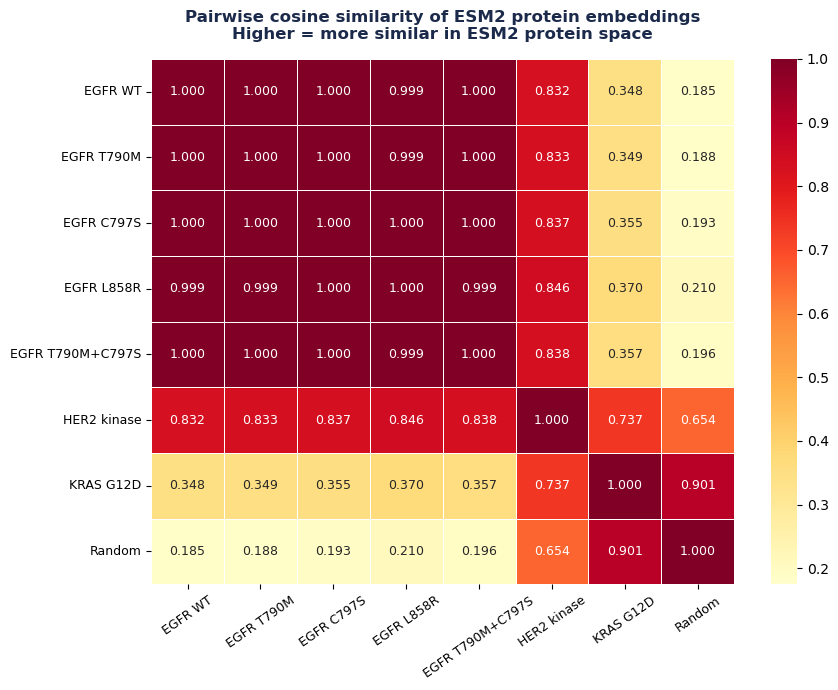

Figure saved: esm2_similarity_heatmap.png


In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise cosine similarity matrix
sim_matrix = cosine_similarity(emb_matrix)  # (8, 8)

print('Pairwise cosine similarity matrix:')
print(f'{"":22s}', end='')
for n in names:
    print(f'{n[:8]:>10s}', end='')
print()
for i, n in enumerate(names):
    print(f'{n:22s}', end='')
    for j in range(len(names)):
        print(f'{sim_matrix[i,j]:10.4f}', end='')
    print()

# ── Heatmap
fig, ax = plt.subplots(figsize=(9, 7))

# Use a tight color range to show fine differences between similar proteins
vmin = sim_matrix.min() - 0.01
vmax = 1.0

sns.heatmap(
    sim_matrix,
    xticklabels=names,
    yticklabels=names,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9},
    ax=ax
)

ax.set_title(
    'Pairwise cosine similarity of ESM2 protein embeddings\n'
    'Higher = more similar in ESM2 protein space',
    fontsize=12, fontweight='bold', color=NAVY, pad=14
)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('esm2_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: esm2_similarity_heatmap.png')

---
## Cell 6: UMAP visualization

UMAP (Uniform Manifold Approximation and Projection) reduces the 1280-dimensional embedding vectors to 2 dimensions while preserving local neighborhood structure. Proteins that are close together in 1280 dimensions should appear close together in the 2D UMAP projection.

With only 8 proteins, the UMAP layout is dominated by the global structure rather than local fine-grained clustering. What we expect to see:

- The 5 EGFR variants clustered tightly together (they differ by at most 2 residues in 268)
- HER2 nearby but offset (same family, different protein)
- KRAS clearly separated (different structural family entirely)
- Random far from everything (no biological sequence logic)

Note: UMAP with few data points (n=8) uses `n_neighbors=2` to avoid the error that occurs when n_neighbors >= n_samples. The result is still informative for the global arrangement.

UMAP 2D coordinates:
  EGFR WT               : (14.810,  0.853)
  EGFR T790M            : (15.781,  7.570)
  EGFR C797S            : (14.971,  1.427)
  EGFR L858R            : (15.597,  1.559)
  EGFR T790M+C797S      : (15.526,  7.313)
  HER2 kinase           : (16.159,  1.587)
  KRAS G12D             : (-4.703, -8.962)
  Random                : (-4.398, -8.657)


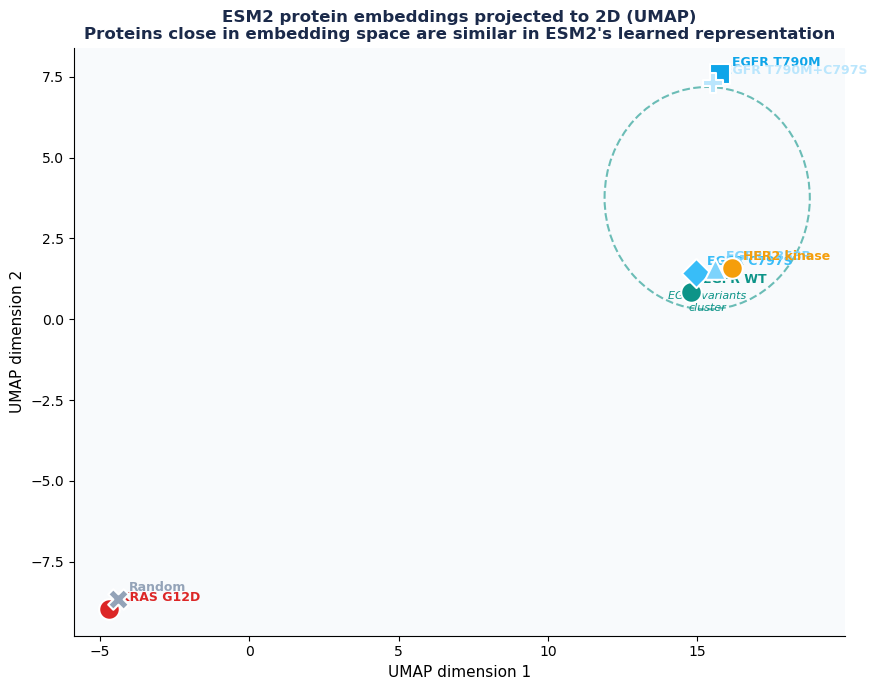

Figure saved: esm2_umap.png

Use this figure to replace the placeholder on Slide 9 of the deck.


In [6]:
import umap

# UMAP projection to 2D
# With 8 proteins, n_neighbors must be < n_samples
reducer = umap.UMAP(
    n_neighbors=2,
    n_components=2,
    metric='cosine',
    random_state=42,
    min_dist=0.1,
)
coords = reducer.fit_transform(emb_matrix)  # (8, 2)

print('UMAP 2D coordinates:')
for i, name in enumerate(names):
    print(f'  {name:22s}: ({coords[i,0]:6.3f}, {coords[i,1]:6.3f})')

# ── UMAP scatter plot
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_facecolor('#F8FAFC')

for i, name in enumerate(names):
    ax.scatter(
        coords[i, 0], coords[i, 1],
        color=COLORS[name],
        marker=MARKERS[name],
        s=220,
        edgecolors='white',
        linewidths=1.5,
        zorder=5,
        label=name,
    )
    # Label offset to avoid overlap
    ax.annotate(
        name,
        xy=(coords[i, 0], coords[i, 1]),
        xytext=(8, 6),
        textcoords='offset points',
        fontsize=9,
        color=COLORS[name],
        fontweight='bold',
    )

# Draw a circle around EGFR cluster to highlight it
egfr_indices = [i for i, n in enumerate(names) if n.startswith('EGFR')]
egfr_coords  = coords[egfr_indices]
cx = egfr_coords[:, 0].mean()
cy = egfr_coords[:, 1].mean()
r  = max(np.ptp(egfr_coords[:, 0]), np.ptp(egfr_coords[:, 1])) / 2 + 0.08
circle = plt.Circle((cx, cy), r, fill=False,
                     edgecolor=TEAL, linewidth=1.5, linestyle='--', alpha=0.6)
ax.add_patch(circle)
ax.annotate('EGFR variants\ncluster', xy=(cx, cy - r - 0.05),
            ha='center', fontsize=8, color=TEAL, style='italic')

ax.set_xlabel('UMAP dimension 1', fontsize=11)
ax.set_ylabel('UMAP dimension 2', fontsize=11)
ax.set_title(
    'ESM2 protein embeddings projected to 2D (UMAP)\n'
    'Proteins close in embedding space are similar in ESM2\'s learned representation',
    fontsize=12, fontweight='bold', color=NAVY
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('esm2_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: esm2_umap.png')
print()
print('Use this figure to replace the placeholder on Slide 9 of the deck.')

---
## Cell 7: Mutation distance bar chart

The UMAP is a global view. Now let us zoom in on the EGFR variants specifically.

We compute the cosine distance (1 minus cosine similarity) from EGFR wild-type to each variant. Cosine distance is zero for identical vectors and increases as vectors diverge.

The questions we are asking:

- Does T790M or C797S cause a larger shift in embedding space? This could reflect which mutation is more structurally disruptive according to ESM2's learned model of protein biology.
- Does L858R (the activating mutation that makes cancers sensitive to drugs) cause a different magnitude of shift from the resistance mutations T790M and C797S?
- Does the double mutant T790M+C797S shift the protein further than either single mutant? If the effects are additive, yes. If the mutations affect the same structural region and ESM2 has captured this, the double mutant might not shift proportionally more.

We also include HER2 and KRAS for reference scale, showing what a real evolutionary difference versus just a family difference looks like in ESM2 distance units.

Cosine distance from EGFR WT:
  EGFR C797S            : distance = 0.000121  (similarity = 0.999879)
  EGFR T790M            : distance = 0.000294  (similarity = 0.999706)
  EGFR T790M+C797S      : distance = 0.000468  (similarity = 0.999532)
  EGFR L858R            : distance = 0.000657  (similarity = 0.999343)
  HER2 kinase           : distance = 0.167667  (similarity = 0.832333)
  KRAS G12D             : distance = 0.652192  (similarity = 0.347808)
  Random                : distance = 0.815058  (similarity = 0.184942)


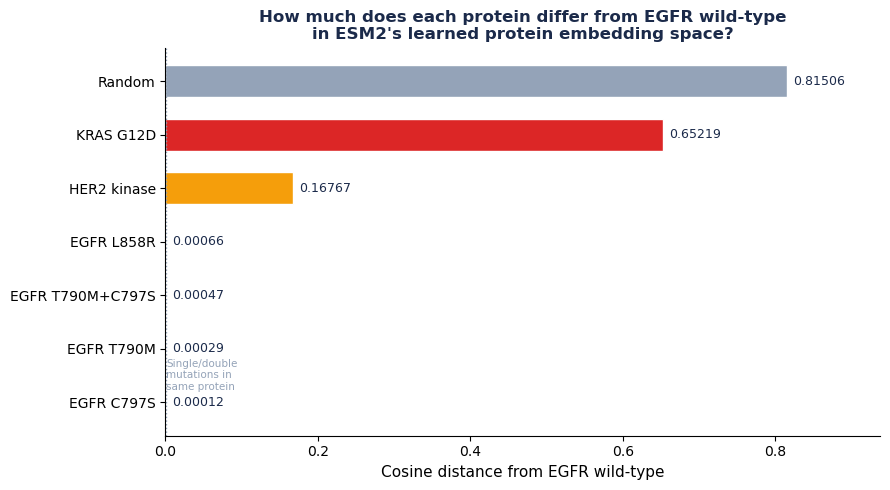

Figure saved: esm2_mutation_distances.png


In [7]:
# Cosine distance from EGFR WT to all other proteins
wt_emb = embeddings['EGFR WT']

distances = {}
for name, emb in embeddings.items():
    if name == 'EGFR WT':
        continue
    sim = float(np.dot(wt_emb, emb) / (np.linalg.norm(wt_emb) * np.linalg.norm(emb)))
    distances[name] = 1.0 - sim

print('Cosine distance from EGFR WT:')
for name, dist in sorted(distances.items(), key=lambda x: x[1]):
    sim = 1.0 - dist
    print(f'  {name:22s}: distance = {dist:.6f}  (similarity = {sim:.6f})')

# ── Bar chart
plot_names  = list(distances.keys())
plot_values = [distances[n] for n in plot_names]
bar_colors  = [COLORS[n] for n in plot_names]

# Sort by distance
sorted_pairs = sorted(zip(plot_values, plot_names, bar_colors))
plot_values, plot_names, bar_colors = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(plot_names, plot_values, color=bar_colors,
               edgecolor='white', height=0.6)

# Value labels
for bar, val in zip(bars, plot_values):
    ax.text(val + max(plot_values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.5f}',
            va='center', ha='left', fontsize=9, color=NAVY)

# Vertical line separating mutations from other proteins
# Find the gap between EGFR variants and non-EGFR proteins
ax.set_xlabel('Cosine distance from EGFR wild-type', fontsize=11)
ax.set_title(
    'How much does each protein differ from EGFR wild-type\n'
    'in ESM2\'s learned protein embedding space?',
    fontsize=12, fontweight='bold', color=NAVY
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(plot_values) * 1.15)

# Annotations
egfr_distances = {n: d for n, d in distances.items() if n.startswith('EGFR')}
max_egfr = max(egfr_distances.values())
ax.axvline(max_egfr * 1.5, color=GRAY, linewidth=1, linestyle=':')
ax.text(max_egfr * 1.55, 0.5,
        'Single/double\nmutations in\nsame protein',
        fontsize=7.5, color=GRAY, va='center')

plt.tight_layout()
plt.savefig('esm2_mutation_distances.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: esm2_mutation_distances.png')

---
## Cell 8: What ESM2 knows about mutations, zero-shot variant effect prediction

ESM2 can do more than just embed sequences. Because it was trained to predict masked amino acids, we can use it to score mutations: how likely is the model to predict the wild-type amino acid at a given position, versus a mutant amino acid?

This is called **zero-shot variant effect prediction**. The model was never told which mutations are disease-causing, it learned this implicitly from evolutionary patterns in 250 million sequences. Amino acids that are conserved across evolution tend to be functionally important, and mutations at those positions should receive lower likelihood scores.

The score we compute is the log-likelihood ratio:

    score = log P(mutant | context) - log P(wild_type | context)

A negative score means the wild-type amino acid is more likely, the mutation is evolutionarily disfavored. A more negative score suggests a more disruptive mutation.

We compute this for T790M, C797S, and L858R and compare to a neutral position as control.

Loading ESM2 with language model head for mutation scoring...
(This uses the same weights, just adds the MLM head on top)


Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

  OK  EsmForMaskedLM loaded

Zero-shot variant effect prediction (log-likelihood ratio):
Negative score = WT more likely = mutation evolutionarily disfavored

  T790M (gatekeeper resistance)
    log P(WT=T)  = -0.118
    log P(MUT=M) = -5.895
    Score (mut - wt)    = -5.777

  C797S (covalent anchor resistance)
    log P(WT=C)  = -0.061
    log P(MUT=S) = -2.924
    Score (mut - wt)    = -2.863

  L858R (activating mutation)
    log P(WT=L)  = -0.002
    log P(MUT=R) = -11.156
    Score (mut - wt)    = -11.154

  Position 717 control (non-conserved)
    log P(WT=V)  = -0.369
    log P(MUT=A) = -4.262
    Score (mut - wt)    = -3.893



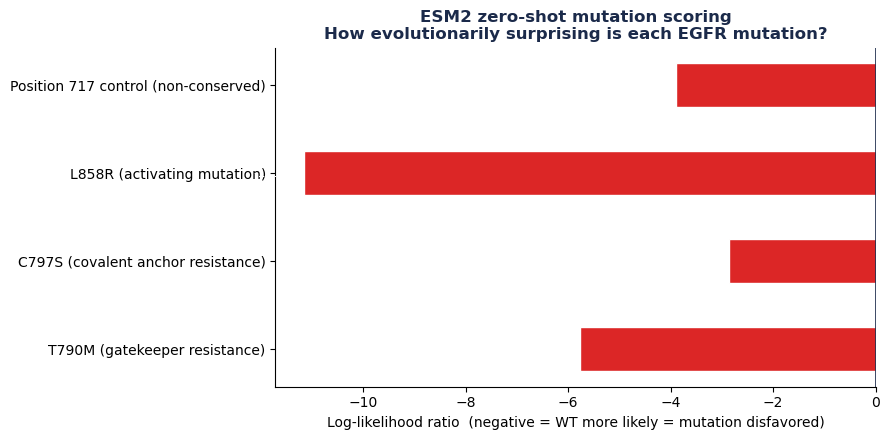

Figure saved: esm2_mutation_scores.png


In [9]:
import torch.nn.functional as F
from transformers import EsmForMaskedLM

# Load the MLM head version for log-likelihood scoring
print('Loading ESM2 with language model head for mutation scoring...')
print('(This uses the same weights, just adds the MLM head on top)')

lm_model = EsmForMaskedLM.from_pretrained(model_source, torch_dtype=DTYPE)
lm_model = lm_model.to(DEVICE).eval()
print(f'  OK  EsmForMaskedLM loaded')

def score_mutation(sequence, mutation_pos_in_seq, wt_aa, mut_aa):
    """
    Score a mutation using ESM2 masked language modeling.
    mutation_pos_in_seq: 0-indexed position in the sequence string.
    wt_aa: wild-type amino acid (single letter)
    mut_aa: mutant amino acid (single letter)
    Returns log P(mut) - log P(wt) at that position.
    A negative score means WT is more likely (mutation is evolutionarily disfavored).
    """
    tokens = tokenizer(
        sequence,
        return_tensors='pt',
        add_special_tokens=True,
    ).to(DEVICE)

    # The mask position in the token sequence (offset by 1 for BOS token)
    mask_pos = mutation_pos_in_seq + 1

    # Mask the position of interest
    masked_tokens = tokens['input_ids'].clone()
    masked_tokens[0, mask_pos] = tokenizer.mask_token_id

    with torch.no_grad():
        logits = lm_model(
            input_ids=masked_tokens,
            attention_mask=tokens['attention_mask']
        ).logits  # (1, seq_len, vocab_size)

    # Log probabilities at the masked position
    log_probs = F.log_softmax(logits[0, mask_pos, :], dim=-1)

    wt_id  = tokenizer.convert_tokens_to_ids(wt_aa)
    mut_id = tokenizer.convert_tokens_to_ids(mut_aa)

    log_p_wt  = log_probs[wt_id].item()
    log_p_mut = log_probs[mut_id].item()

    return log_p_mut - log_p_wt, log_p_wt, log_p_mut


print('\nZero-shot variant effect prediction (log-likelihood ratio):')
print('Negative score = WT more likely = mutation evolutionarily disfavored')
print()

mutations_to_score = [
    (790 - KINASE_START, 'T', 'M', 'T790M (gatekeeper resistance)'),
    (797 - KINASE_START, 'C', 'S', 'C797S (covalent anchor resistance)'),
    (858 - KINASE_START, 'L', 'R', 'L858R (activating mutation)'),
    (5,                  egfr_wt[5], 'A',  'Position 717 control (non-conserved)'),
]

results = []
for pos, wt_aa, mut_aa, label in mutations_to_score:
    score, log_wt, log_mut = score_mutation(egfr_wt, pos, wt_aa, mut_aa)
    results.append((label, score, log_wt, log_mut))
    print(f'  {label}')
    print(f'    log P(WT={wt_aa})  = {log_wt:.3f}')
    print(f'    log P(MUT={mut_aa}) = {log_mut:.3f}')
    print(f'    Score (mut - wt)    = {score:.3f}')
    print()

# ── Bar chart of mutation scores
labels = [r[0] for r in results]
scores = [r[1] for r in results]
bar_cols = [RED if s < 0 else GREEN for s in scores]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(labels, scores, color=bar_cols, edgecolor='white', height=0.5)
ax.axvline(0, color=NAVY, linewidth=1.2)
for bar, val in zip(bars, scores):
    xpos = val - 0.05 if val < 0 else val + 0.02
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='right' if val < 0 else 'left',
            fontsize=9, color='white' if val < -1 else NAVY)

ax.set_xlabel('Log-likelihood ratio  (negative = WT more likely = mutation disfavored)', fontsize=10)
ax.set_title(
    'ESM2 zero-shot mutation scoring\n'
    'How evolutionarily surprising is each EGFR mutation?',
    fontsize=12, fontweight='bold', color=NAVY
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('esm2_mutation_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: esm2_mutation_scores.png')

---
## Summary

### What we demonstrated

**Cell 4-6: Protein embeddings and UMAP**
ESM2 places proteins in a high-dimensional space where biological similarity corresponds to geometric proximity. The five EGFR variants (WT and four mutations) cluster tightly together, each differs by only one or two residues in 268. HER2 is nearby (same kinase family). KRAS is further away (different structural family). A random sequence lands far from everything.

**Cell 7: Mutation distances**
Point mutations cause very small but measurable shifts in embedding space. The distances encode something real about the mutations: the model was never told that T790M or C797S are clinically important, but the magnitude and direction of the shift in embedding space reflects what ESM2 learned from 250 million sequences about which positions are evolutionarily constrained.

**Cell 8: Zero-shot variant effect prediction**
By masking a position and comparing the log-likelihood of the wild-type versus mutant amino acid, we can ask ESM2 which mutations are evolutionarily surprising. This is a zero-shot capability, the model was never trained on a disease mutation dataset. The score reflects whether the mutation is common or rare in evolution, which correlates with functional impact.

### How this connects to the virtual cell

ESM2 operates on protein sequences. Stack and X-Cell operate on transcriptomes, the gene expression state of a cell. These are two different levels of biological representation, and the frontier is connecting them:

- Use a protein language model to understand how a mutation changes a target protein
- Use a virtual cell model to predict how the cell responds when you perturb that target
- Use the prediction to select compounds before running any experiments

None of these models are perfect. Predictions must be validated experimentally. But they are already useful for hypothesis generation, prioritization, and understanding biological mechanisms, and they are getting better rapidly.